# 05 · Heterogeneous effects, uplift modeling, and targeting decisions

The central question: **does targeting by predicted uplift find more incremental outcomes than targeting the users
most likely to convert?** CATE(x) = E[Y(1) − Y(0) | X = x] is estimated with S-, T-, X-, DR-learners, a causal
forest and a transformed-outcome learner, all trained on the training split, selected on validation, and evaluated
once on the 2.8M-user test split. Uplift quantities are propensity-weighted (Hajek) because treatment is not
independent of the features here (notebook 04).

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils import REPO_ROOT

FIG, TAB, MET = (REPO_ROOT / "results" / d for d in ("figures", "tables", "metrics"))
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
pd.set_option("display.max_colwidth", 120)

def fig(name, width=950):
    display(Image(filename=str(FIG / f"{name}.png"), width=width))

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def metrics(name):
    return json.loads((MET / f"{name}.json").read_text())

In [2]:
cate = metrics("cate")
print("selected on validation:", cate["selected_learner"])
m = table("cate_uplift_metrics")
m[(m.estimator == "ipw") & (m.metric == "qini_normalized")].pivot(index="scorer", columns="outcome", values="estimate")

selected on validation: {'visit': 'x_learner', 'conversion': 'causal_forest'}


outcome,conversion,visit
scorer,,
causal_forest,0.1736,0.07396
class_transformation,0.1724,0.07448
dr_learner,0.1694,0.07813
random,0.004827,-0.000581
response,0.1815,0.07289
s_learner,0.1737,0.0777
t_learner,0.1339,0.07133
x_learner,0.1733,0.07732


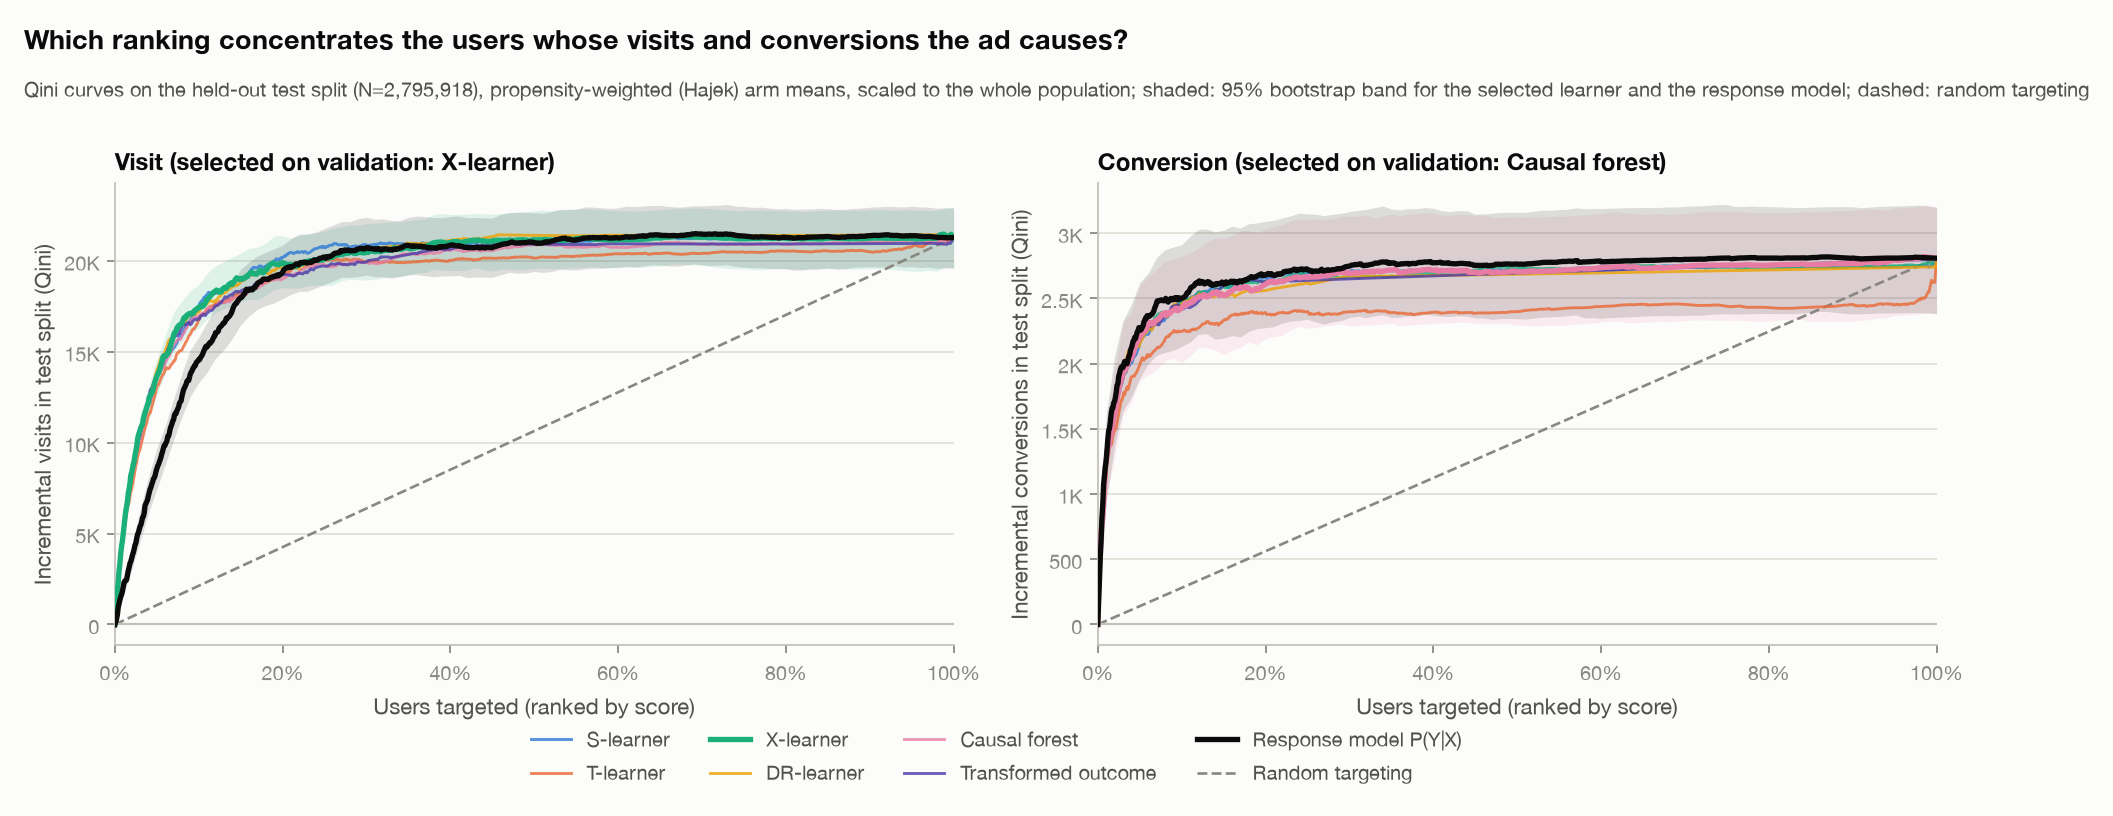

In [3]:
fig("cate_qini_curves")

## Uplift targeting vs conversion-probability targeting

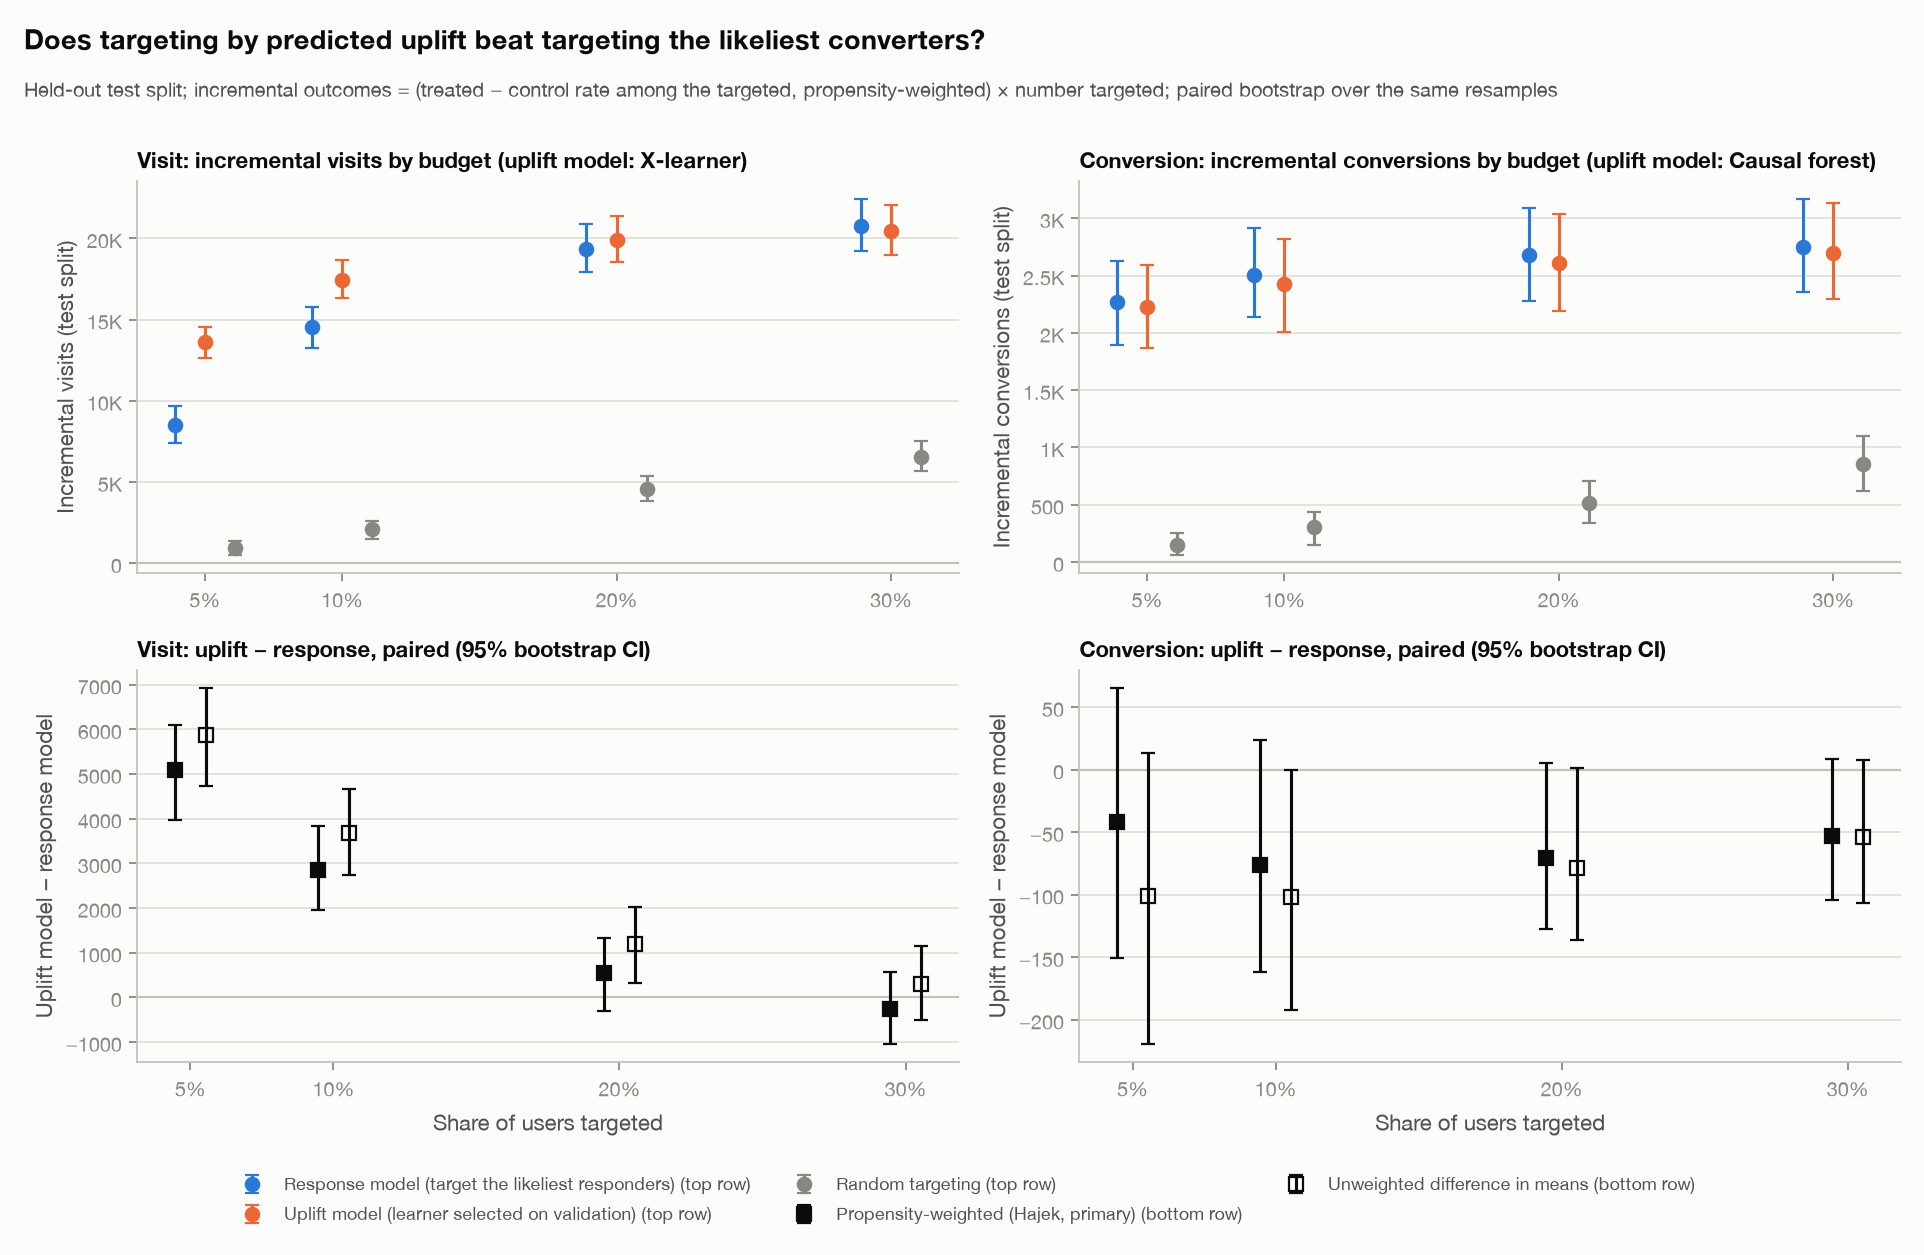

,outcome,estimator,scorer_a,scorer_b,metric,estimate,ci_low,ci_high,p_boot
182,visit,ipw,s_learner,response,ate,-3.227e-16,-2.221e-16,2.538e-16,0.93
183,visit,ipw,s_learner,response,qini_coefficient,0.000207,4.566e-05,0.0003491,0.01
184,visit,ipw,s_learner,response,auuc,0.0002069,4.624e-05,0.000349,0.01
185,visit,ipw,s_learner,response,auuc_random,-1.631e-16,-1.11e-16,1.257e-16,0.93
186,visit,ipw,s_learner,response,qini_normalized,0.004811,0.001059,0.008153,0.01
...,...,...,...,...,...,...,...,...,...
723,conversion,ipw,response,random,uplift_at_30,0.00226,0.001865,0.002672,0
724,conversion,ipw,response,random,incremental_at_30,"1,896","1,562","2,243",0
725,conversion,ipw,response,random,treated_rate_at_30,0.006838,0.006642,0.007036,0
726,conversion,ipw,response,random,control_rate_at_30,0.004578,0.004209,0.004967,0


In [4]:
fig("cate_response_vs_uplift")
d = table("cate_uplift_differences")
d[d.estimator == "ipw"]

**Visits:** at small budgets the uplift model finds substantially more incremental visits than the response model,
because the users most likely to visit mostly visit anyway ("sure things"). **Conversions:** no uplift learner beats
the response model. The share of conversions that would have happened anyway is roughly flat across score groups, so
the ad scales conversion roughly in proportion to the baseline rate, and the likeliest converters are also the users
with the largest absolute uplift.

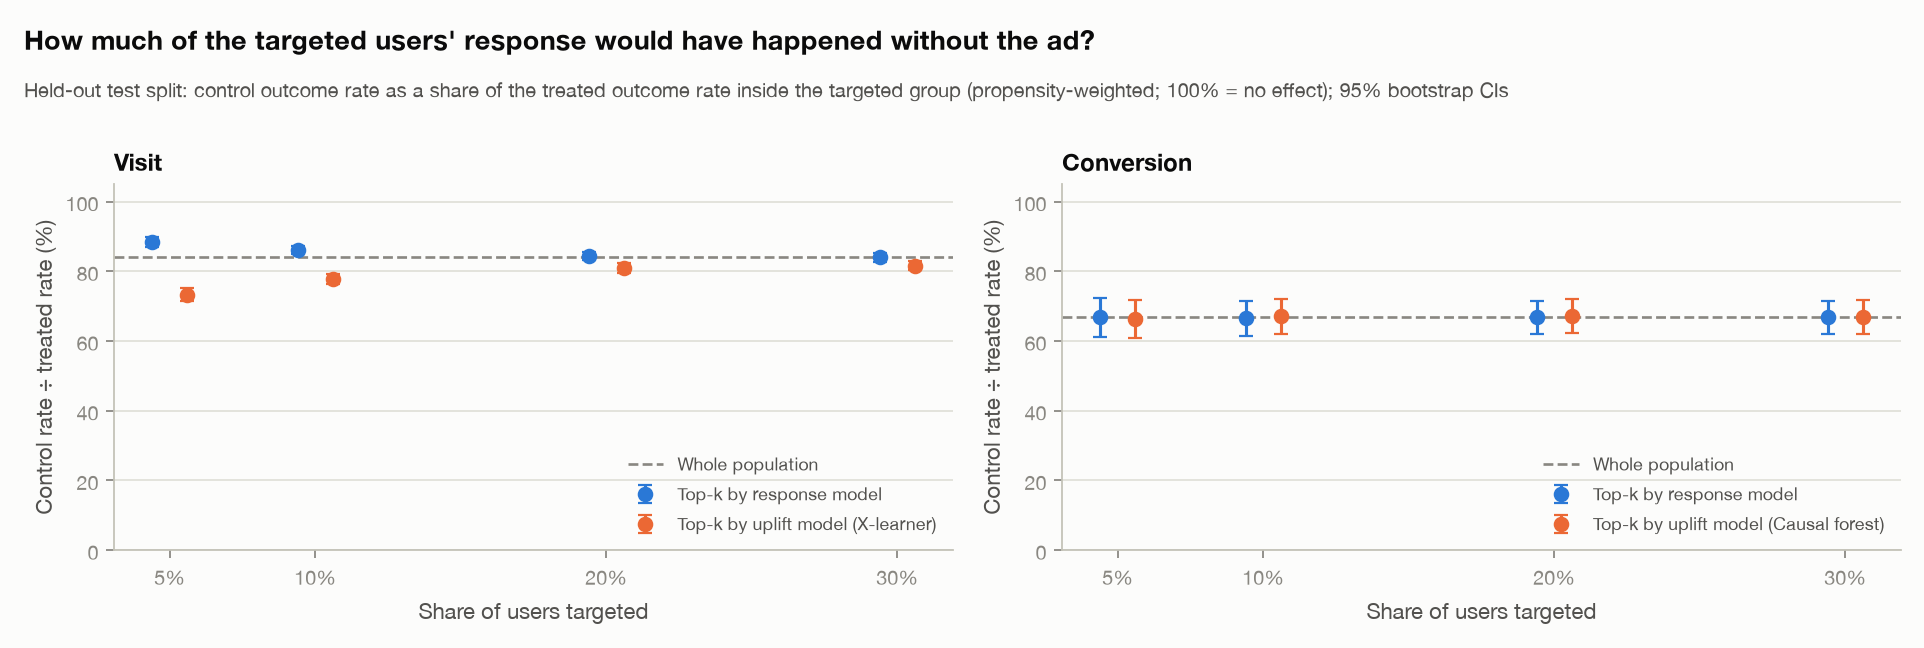

In [5]:
fig("cate_sure_things")

## Reproducing one number from the saved scores

In [6]:
from src.causal.uplift_metrics import uplift_at_k

s = pd.read_parquet(REPO_ROOT / "data/processed/scores_full.parquet",
                    columns=["split", "treatment", "visit", "response_visit", "cate_x_learner_visit"])
s = s[s.split == 2]
for name in ["cate_x_learner_visit", "response_visit"]:
    print(f"{name:22s} uplift in the top 5% (unweighted): {uplift_at_k(s.visit.to_numpy(), s.treatment.to_numpy(), s[name].to_numpy(), 0.05):.4f}")

cate_x_learner_visit   uplift in the top 5% (unweighted): 0.0967


response_visit         uplift in the top 5% (unweighted): 0.0546


## Treatment-effect heterogeneity

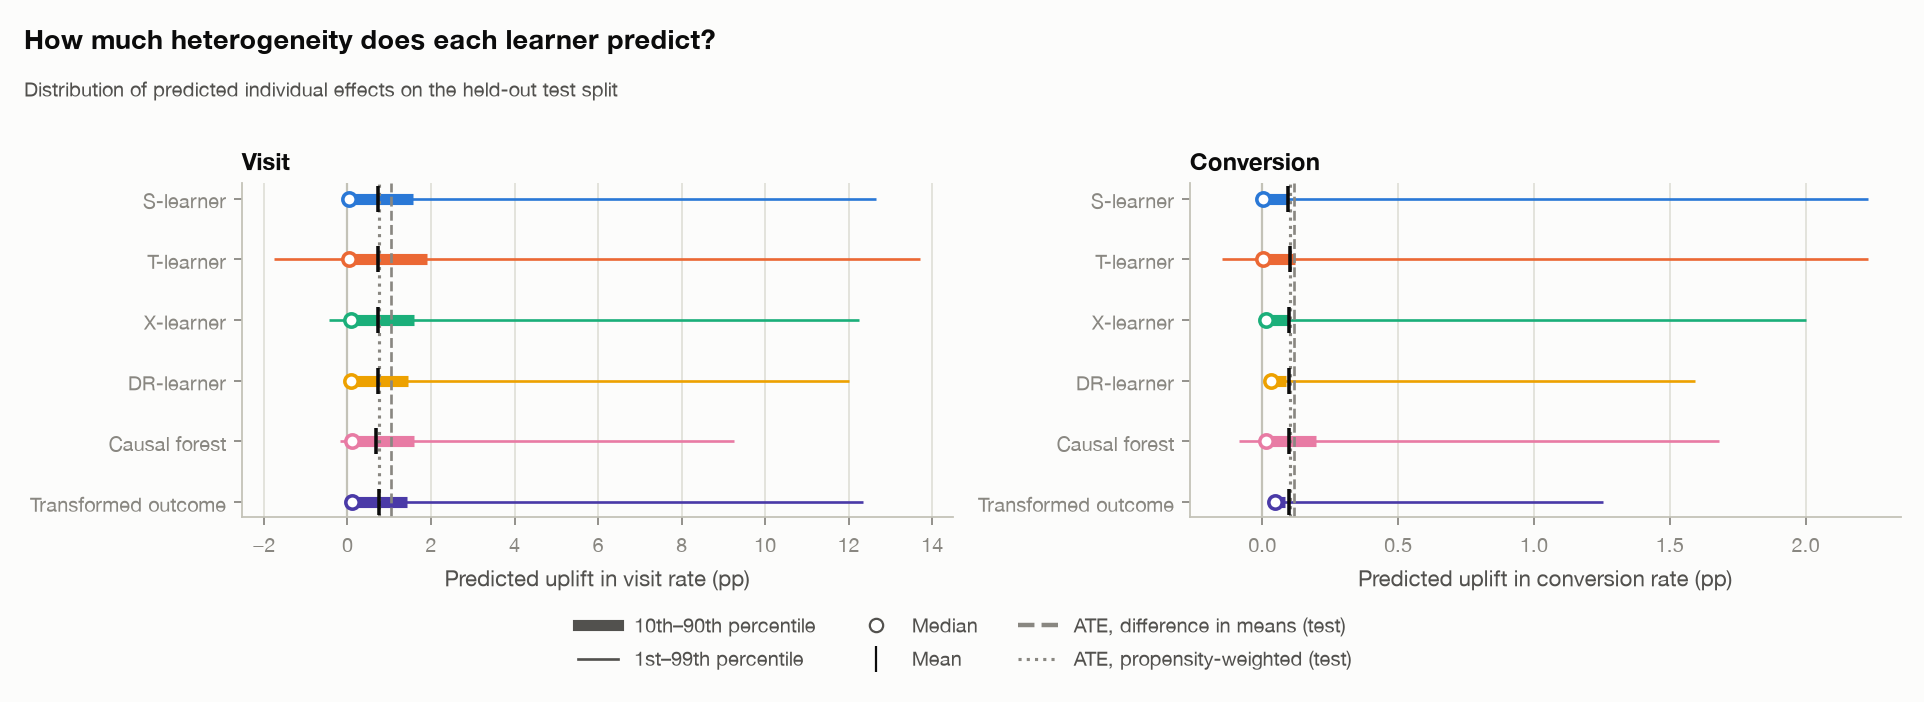

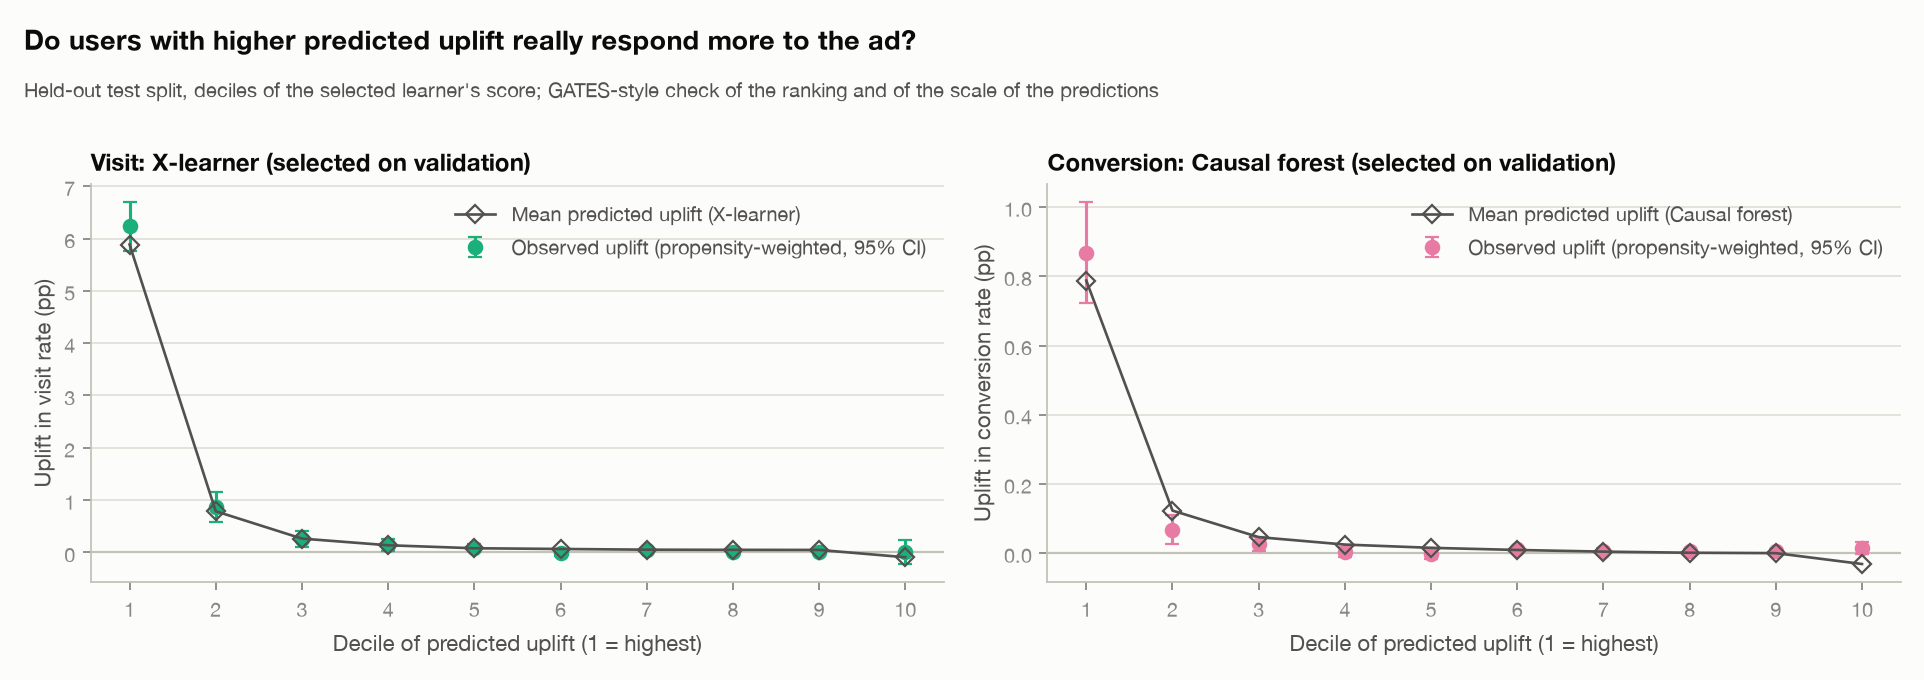

{
 "visit": {
  "s_learner": {
   "outcome": "visit",
   "ate_beta1": 0.007432009010856149,
   "ate_beta1_se": 0.00028598470911867766,
   "beta2": 1.0187082067387752,
   "beta2_se": 0.03599054381159124,
   "beta2_ci_low": 0.9481667408680563,
   "beta2_ci_high": 1.089249672609494,
   "beta2_z": 28.304885085139684,
   "p_value_one_sided": 1.5045581631691498e-176,
   "p_value_two_sided": 3.0091163263382995e-176,
   "score_sd": 0.023577382817169954,
   "n": 2795918
  },
  "t_learner": {
   "outcome": "visit",
   "ate_beta1": 0.00740687296514476,
   "ate_beta1_se": 0.00028573082675248363,
   "beta2": 0.843467709943091,
   "beta2_se": 0.03202078903550146,
   "beta2_ci_low": 0.7807069634335081,
   "beta2_ci_high": 0.9062284564526738,
   "beta2_z": 26.34125314675844,
   "p_value_one_sided": 3.2323185584896917e-153,
   "p_value_two_sided": 6.464637116979383e-153,
   "score_sd": 0.02631441777944881,
   "n": 2795918
  },
  "x_learner": {
   "outcome": "visit",
   "ate_beta1": 0.007425855908528155

In [7]:
fig("cate_tau_distributions"); fig("cate_uplift_calibration"); print(json.dumps(cate["blp"], indent=1, default=str)[:1500])

The BLP test (Chernozhukov et al.) asks whether the predicted effects carry real signal about the true effects; a
slope near 1 means they are well scaled. Predicted *negative* effects are a different story:

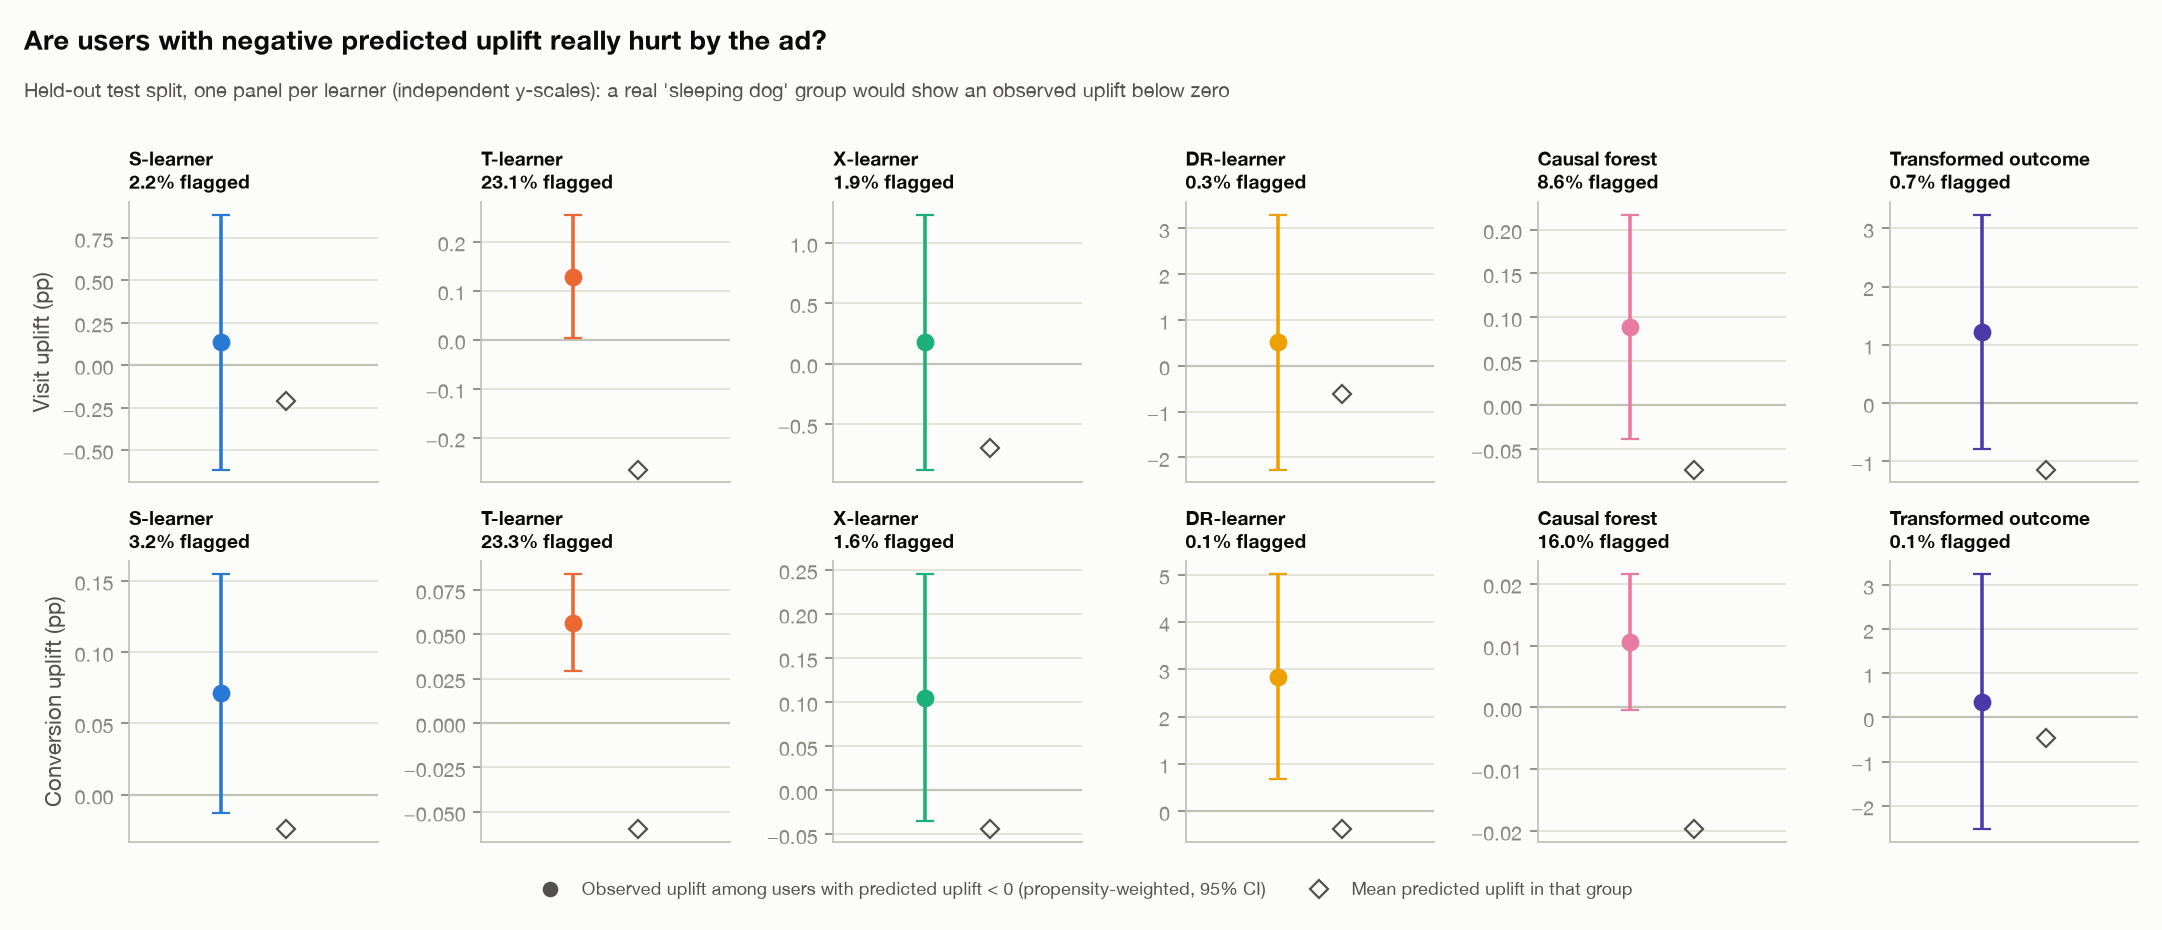

,outcome,learner,share_predicted_negative,n_predicted_negative,mean_predicted,observed,ci_low,ci_high,observed_dim,ci_low_dim,ci_high_dim,treated_rate,control_rate,bottom_decile_mean_predicted,bottom_decile_observed,bottom_decile_ci_low,bottom_decile_ci_high
0,visit,s_learner,0.02201,61549,-0.002105,0.001355,-0.006161,0.008871,0.0009739,-0.006552,0.0085,0.1361,0.1347,-0.0004312,5.922e-05,-0.001726,0.001845
1,visit,t_learner,0.2314,646994,-0.002648,0.001289,2.822e-05,0.002551,0.001404,0.0001466,0.002662,0.0367,0.03541,-0.006019,0.002771,-3.285e-05,0.005575
2,visit,x_learner,0.01875,52426,-0.006949,0.00179,-0.008764,0.01234,0.001381,-0.009178,0.01194,0.2738,0.272,-0.0009101,0.000127,-0.002202,0.002456
3,visit,dr_learner,0.003354,9378,-0.00622,0.005162,-0.02267,0.033,0.008081,-0.01974,0.0359,0.4797,0.4745,0.0004917,-0.0003514,-0.001806,0.001103
4,visit,causal_forest,0.08584,239991,-0.0007334,0.0008923,-0.0003843,0.002169,0.0007522,-0.000533,0.002037,0.01425,0.01336,-0.0006253,0.000917,-0.0001985,0.002033
5,visit,class_transformation,0.006678,18670,-0.01139,0.01221,-0.007892,0.03231,0.01526,-0.004815,0.03534,0.5,0.4878,-4.859e-06,0.001307,-0.00068,0.003295
6,conversion,s_learner,0.03235,90453,-0.0002402,0.0007102,-0.0001268,0.001547,0.000704,-0.0001347,0.001543,0.002738,0.002028,-6.964e-05,0.0002164,-6.938e-05,0.0005022
7,conversion,t_learner,0.2327,650607,-0.0005963,0.0005642,0.0002904,0.0008379,0.0006164,0.0003483,0.0008846,0.00207,0.001506,-0.001377,0.001273,0.0006465,0.001899
8,conversion,x_learner,0.01566,43784,-0.0004377,0.00105,-0.0003495,0.00245,0.001026,-0.000381,0.002434,0.003767,0.002716,3.858e-05,0.0002471,-2.345e-06,0.0004965
9,conversion,dr_learner,0.0009564,2674,-0.003764,0.02843,0.006718,0.05014,0.02777,0.005809,0.04973,0.06815,0.03972,0.0002897,0.0003321,6.865e-05,0.0005955


In [8]:
fig("cate_negative_uplift"); table("cate_negative_uplift")

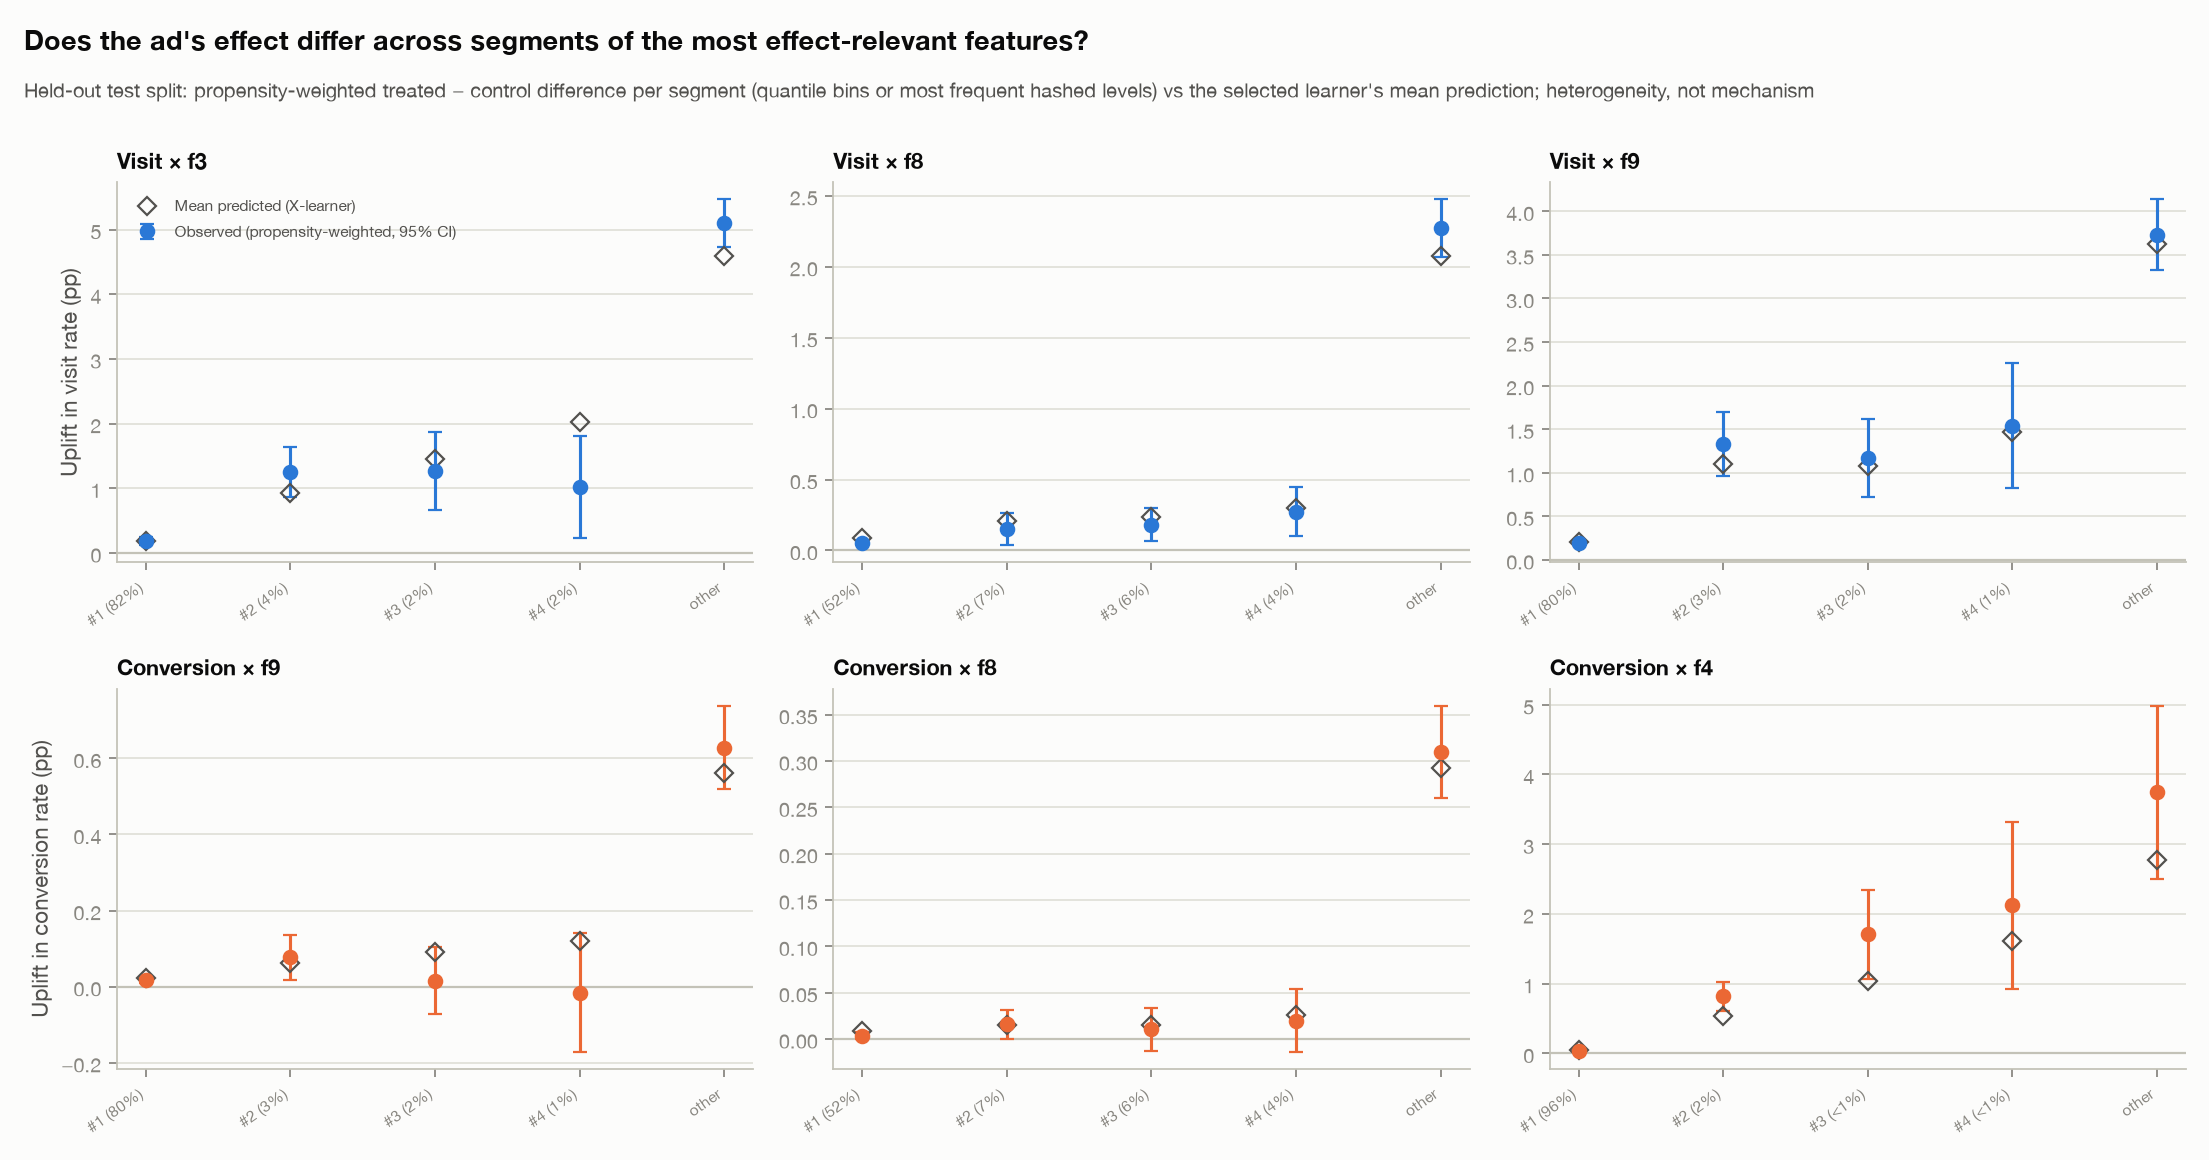

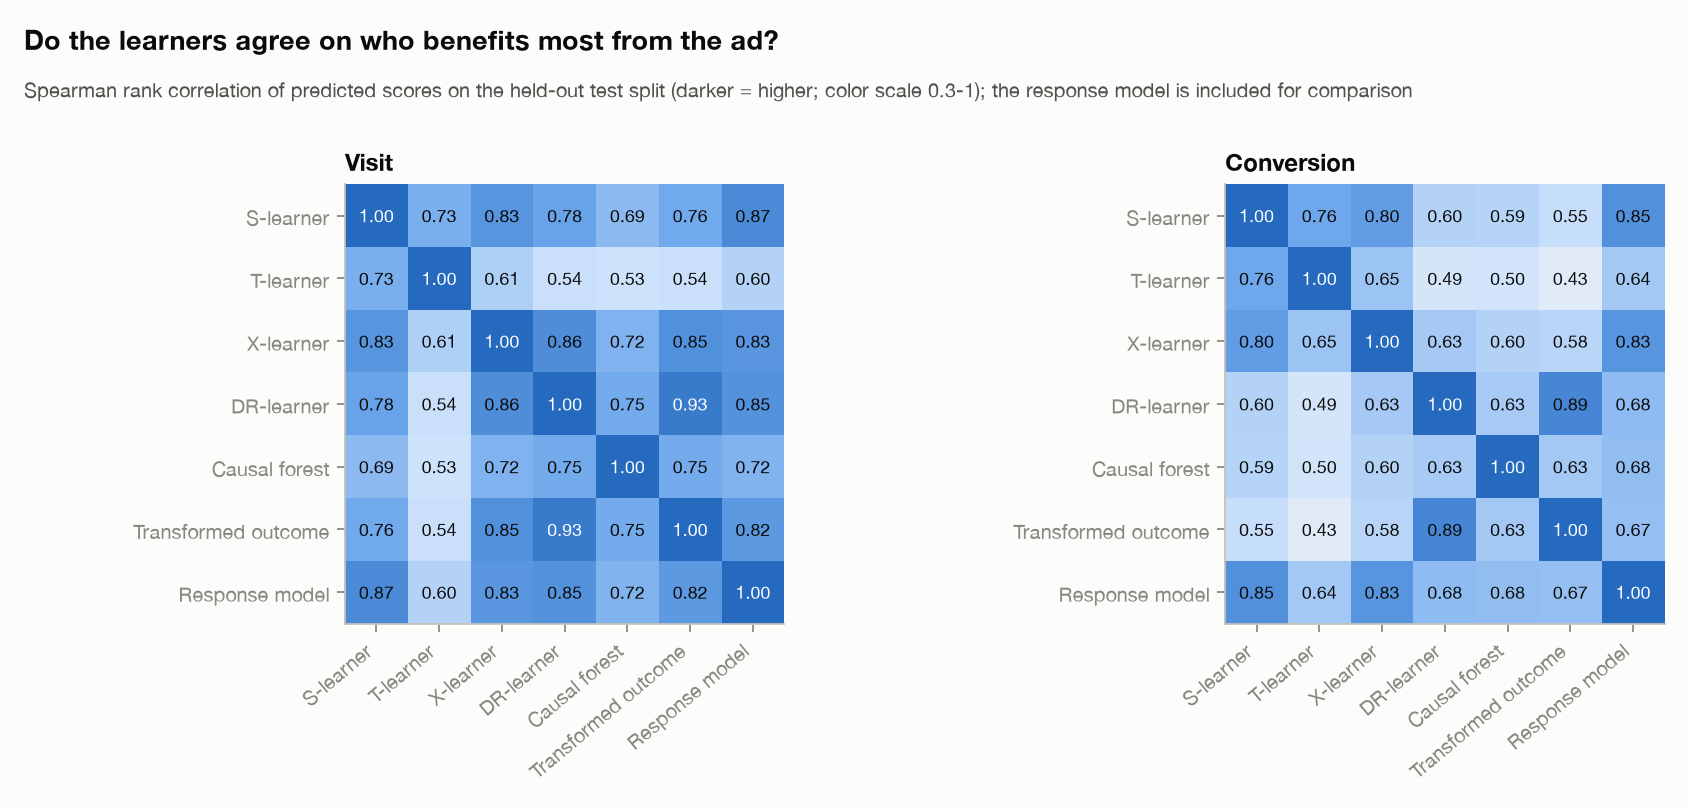

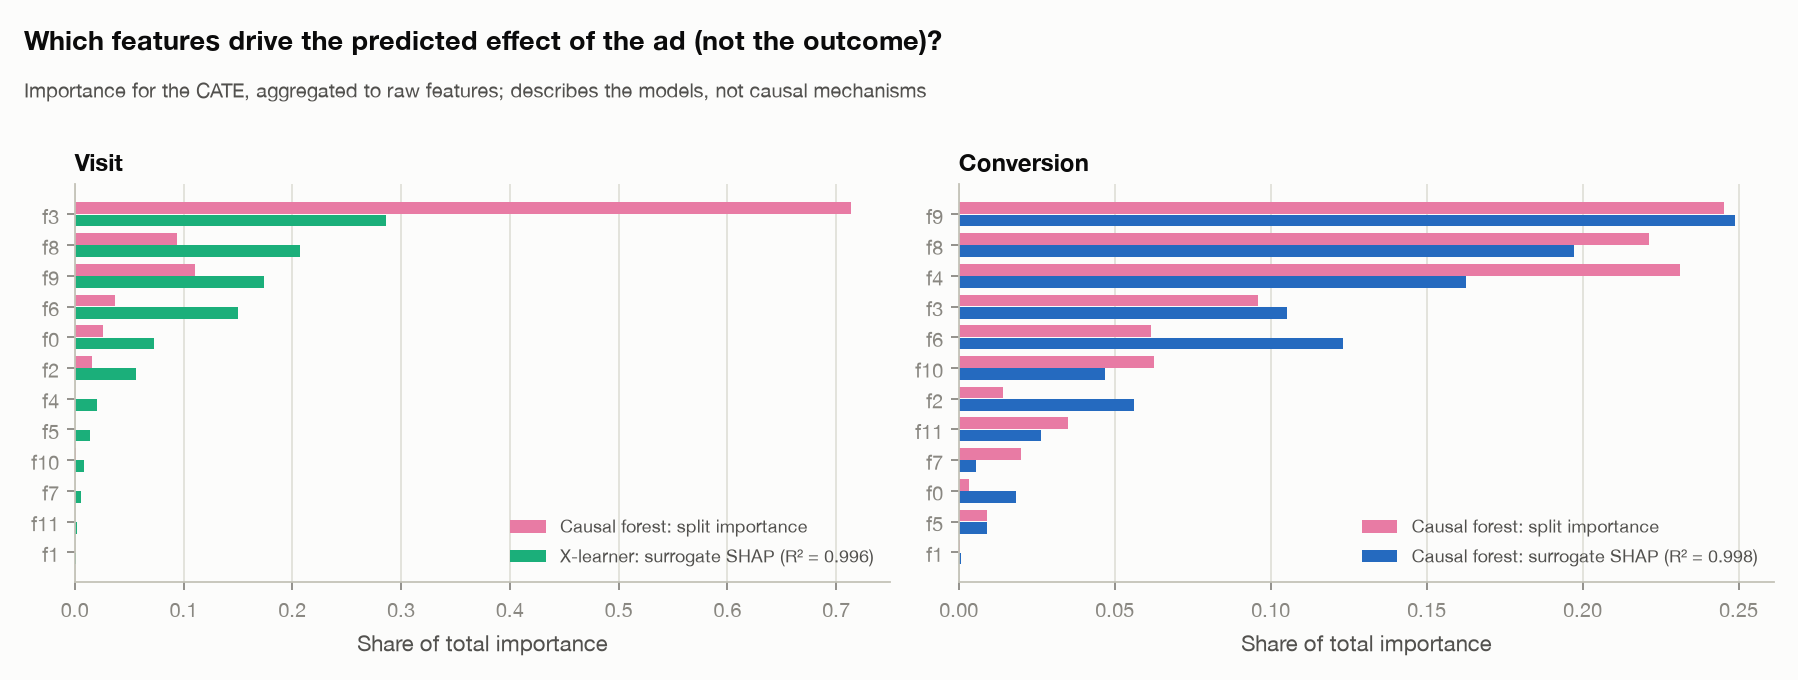

In [9]:
fig("cate_segment_uplift"); fig("cate_rank_correlation"); fig("cate_effect_importance")

## Predicting conversion is not predicting the treatment effect

Feature importance for the conversion model (notebook 03) versus for the effect model:

In [10]:
pi = table("predict_feature_importance").set_index("raw_feature")[["shap_share"]]
pi.columns = ["conversion model: SHAP share"]
ei = table("cate_effect_importance")
ei = ei.assign(share=ei.importance / ei.groupby(["outcome", "method", "learner"]).importance.transform("sum"))
eff = ei.pivot_table(index="feature", columns=["outcome", "method"], values="share")
eff.columns = [f"effect ({o}): {m}" for o, m in eff.columns]
cmp = pd.concat([pi, eff], axis=1).sort_values(pi.columns[0], ascending=False)
print("Spearman rank correlation between conversion importance and each effect importance:")
print(cmp.corr(method="spearman").iloc[0, 1:].round(2).to_string())
cmp

Spearman rank correlation between conversion importance and each effect importance:
effect (conversion): causal_forest_split_importance   0.46
effect (conversion): surrogate_tree_shap              0.55
effect (visit): causal_forest_split_importance        0.78
effect (visit): surrogate_tree_shap                   0.71


,conversion model: SHAP share,effect (conversion): causal_forest_split_importance,effect (conversion): surrogate_tree_shap,effect (visit): causal_forest_split_importance,effect (visit): surrogate_tree_shap
f8,0.4012,0.2211,0.08828,0.09395,0.1882
f2,0.1486,0.01429,0.07652,0.01599,0.05276
f9,0.1232,0.2455,0.172,0.1106,0.1921
f6,0.1043,0.06173,0.09623,0.03735,0.1507
f0,0.08663,0.003372,0.04126,0.02605,0.08105
f10,0.04992,0.06276,0.04811,0.001245,0.007453
f3,0.03385,0.09582,0.1552,0.7138,0.2881
f4,0.02735,0.2313,0.2348,0.0003731,0.01876
f7,0.01416,0.0199,0.01288,0.0004697,0.008118
f11,0.009712,0.03497,0.06667,2.615e-05,0.002424


## Decision optimization under a budget

Expected incremental value of treating a user = τ̂(x) × value − cost. Value and cost are illustrative assumptions
(the benchmark is sub-sampled, so absolute rates are not real-world). Policies are evaluated off-policy on the
randomized test split with propensity weights.

In [11]:
tg = metrics("targeting")
print({k: tg[k] for k in ("value_per_conversion", "cost_per_treatment", "cost_value_ratio_default", "ate_test", "selected_learner")})
table("targeting_policy_values").head(30)

{'value_per_conversion': 50.0, 'cost_per_treatment': 0.05, 'cost_value_ratio_default': 0.001, 'ate_test': {'estimate': 0.001004461125152387, 'ci_lo': 0.0008463987379520419, 'ci_hi': 0.0011471510775446468, 'note': 'treat_all incremental conversions per user; c/V above this makes blanket treatment unprofitable'}, 'selected_learner': 'causal_forest'}


,policy,budget,n_treated,frac_treated,inc_ht,inc_dim,inc,inc_lo,inc_hi,inc_per_100k,...,diff_vs_response_net_hi,diff_vs_random_inc,diff_vs_random_inc_lo,diff_vs_random_inc_hi,diff_vs_random_net,diff_vs_random_net_lo,diff_vs_random_net_hi,random_minus_k_treat_all,random_minus_k_treat_all_lo,random_minus_k_treat_all_hi
0,random,0.05,1.398e+05,0.05,165.5,189.9,165.5,61.59,264.9,5.918,...,-8.598e+04,0,0,0,0,0,0,25.04,-77.29,116.6
1,response,0.05,1.398e+05,0.05,"2,265","1,923","2,269","1,879","2,658",81.16,...,0,"2,104","1,719","2,490",1.052e+05,8.598e+04,1.245e+05,NaN,NaN,NaN
2,uplift,0.05,1.398e+05,0.05,"2,237","1,822","2,227","1,860","2,606",79.66,...,"3,974","2,062","1,680","2,428",1.031e+05,8.4e+04,1.214e+05,NaN,NaN,NaN
3,expected_value,0.05,1.398e+05,0.05,"2,237","1,822","2,227","1,860","2,606",79.66,...,"3,974","2,062","1,680","2,428",1.031e+05,8.4e+04,1.214e+05,NaN,NaN,NaN
4,random,0.1,2.796e+05,0.1,344.7,387.9,342.9,202.1,470,12.27,...,-8.611e+04,0,0,0,0,0,0,62.1,-69.08,182.9
5,response,0.1,2.796e+05,0.1,"2,506","2,365","2,503","2,044","2,915",89.53,...,0,"2,160","1,722","2,557",1.08e+05,8.611e+04,1.278e+05,NaN,NaN,NaN
6,uplift,0.1,2.796e+05,0.1,"2,419","2,263","2,427","2,000","2,829",86.8,...,592.8,"2,084","1,653","2,459",1.042e+05,8.265e+04,1.229e+05,NaN,NaN,NaN
7,expected_value,0.1,2.796e+05,0.1,"2,419","2,263","2,427","2,000","2,829",86.8,...,592.8,"2,084","1,653","2,459",1.042e+05,8.265e+04,1.229e+05,NaN,NaN,NaN
8,random,0.2,5.592e+05,0.2,642.5,730.2,641.3,449.7,826.1,22.94,...,-8.422e+04,0,0,0,0,0,0,79.6,-95.18,238.9
9,response,0.2,5.592e+05,0.2,"2,666","2,777","2,681","2,267","3,076",95.87,...,0,"2,039","1,685","2,406",1.02e+05,8.422e+04,1.203e+05,NaN,NaN,NaN


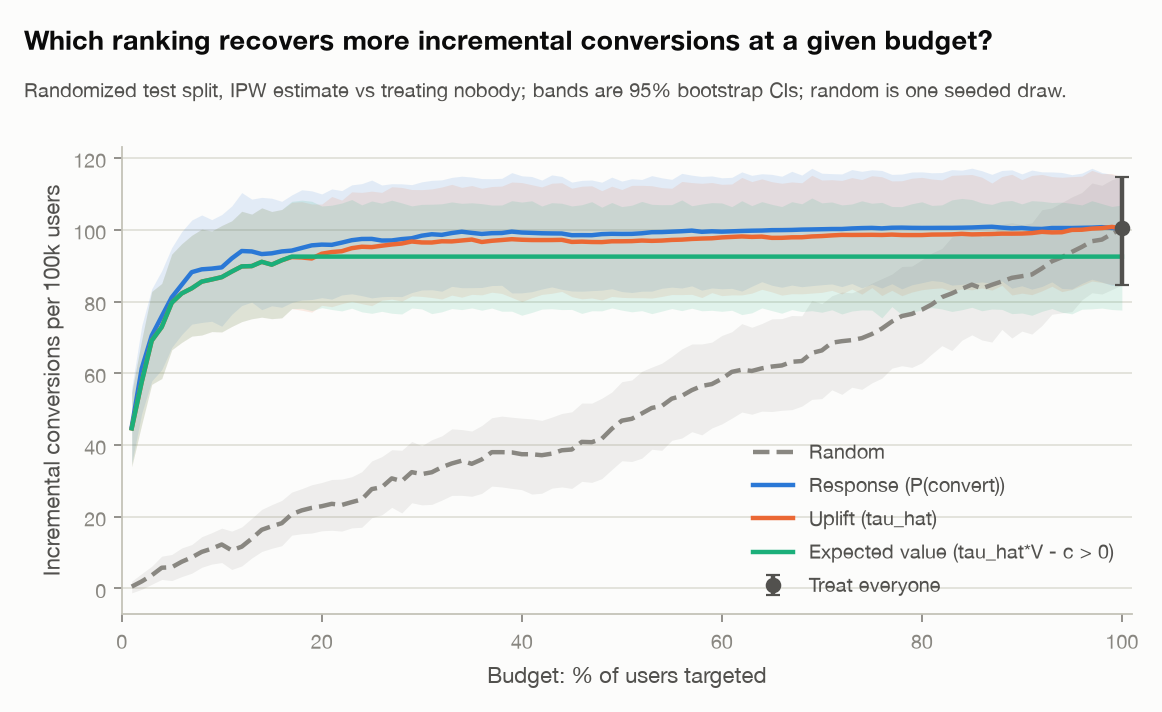

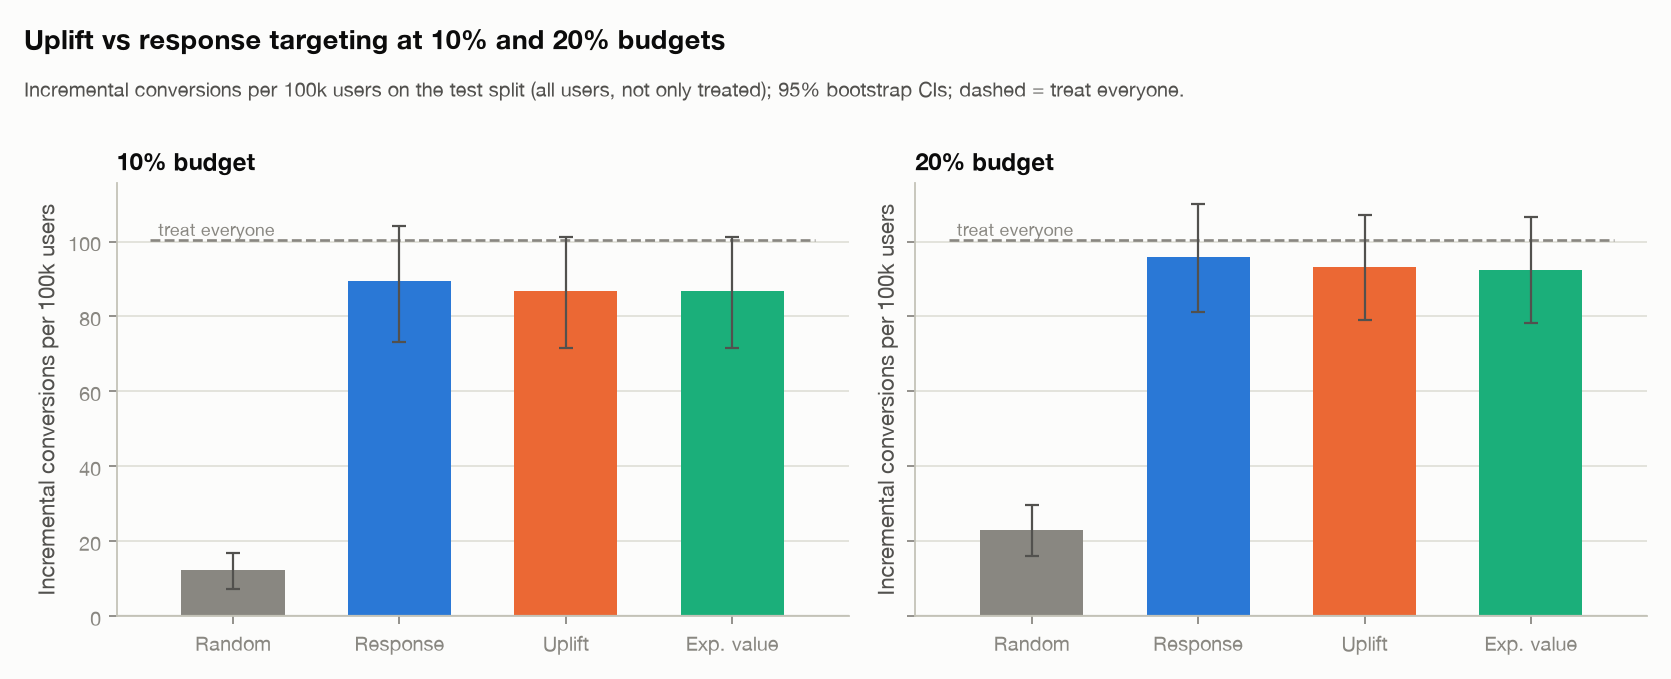

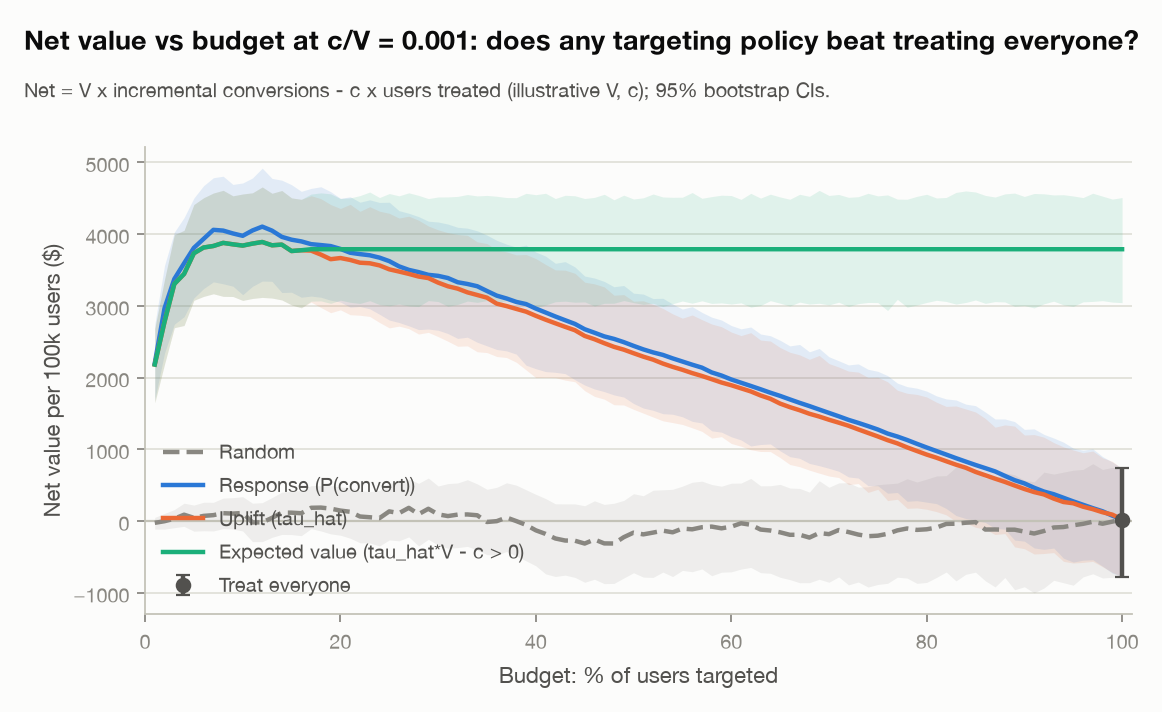

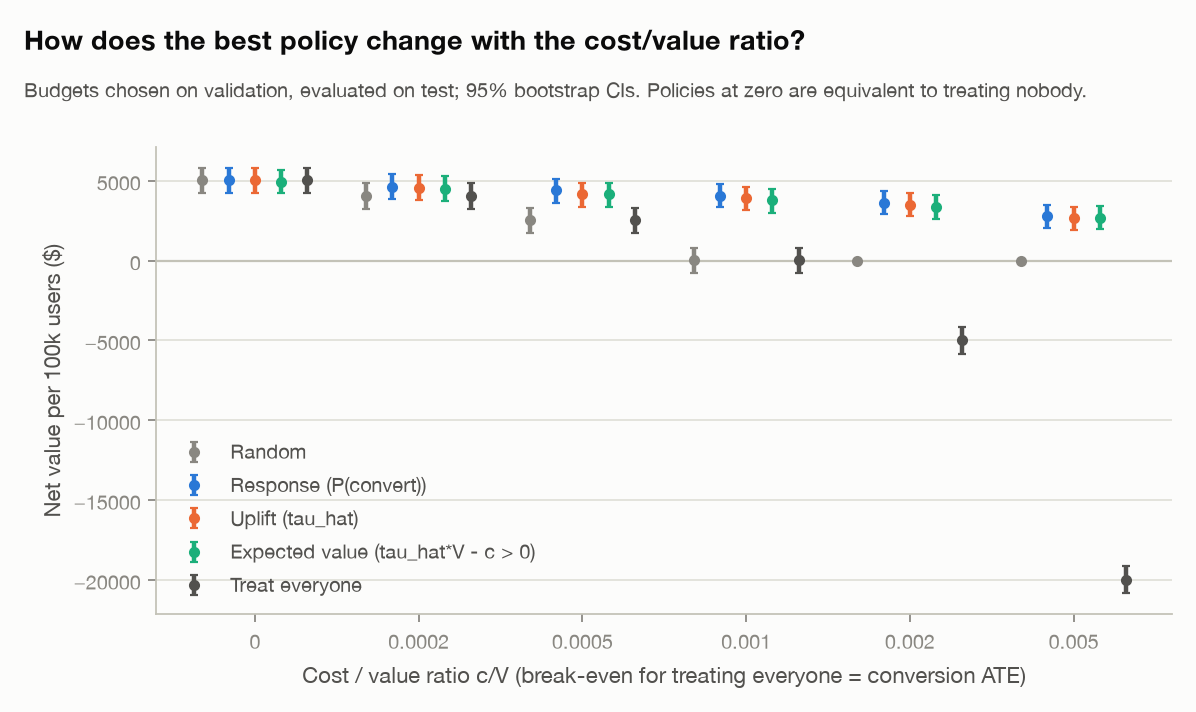

In [12]:
fig("targeting_incremental_vs_budget"); fig("targeting_policy_bars"); fig("targeting_net_value_vs_budget"); fig("targeting_cost_sensitivity")

## Robustness: seeds, training halves, sample size

{
 "visit": {
  "learner": "x_learner",
  "seed_rank_corr_mean": 0.9763160363205178,
  "seed_top10_jaccard_mean": 0.9276120516987417,
  "split_half_rank_corr": 0.815650317868778,
  "split_half_top10_jaccard": 0.6995595972244595
 },
 "conversion": {
  "learner": "causal_forest",
  "seed_rank_corr_mean": 0.49170230107806906,
  "seed_top10_jaccard_mean": 0.6248687869225241,
  "split_half_rank_corr": 0.4007968021264927,
  "split_half_top10_jaccard": 0.6797507937890699
 }
}


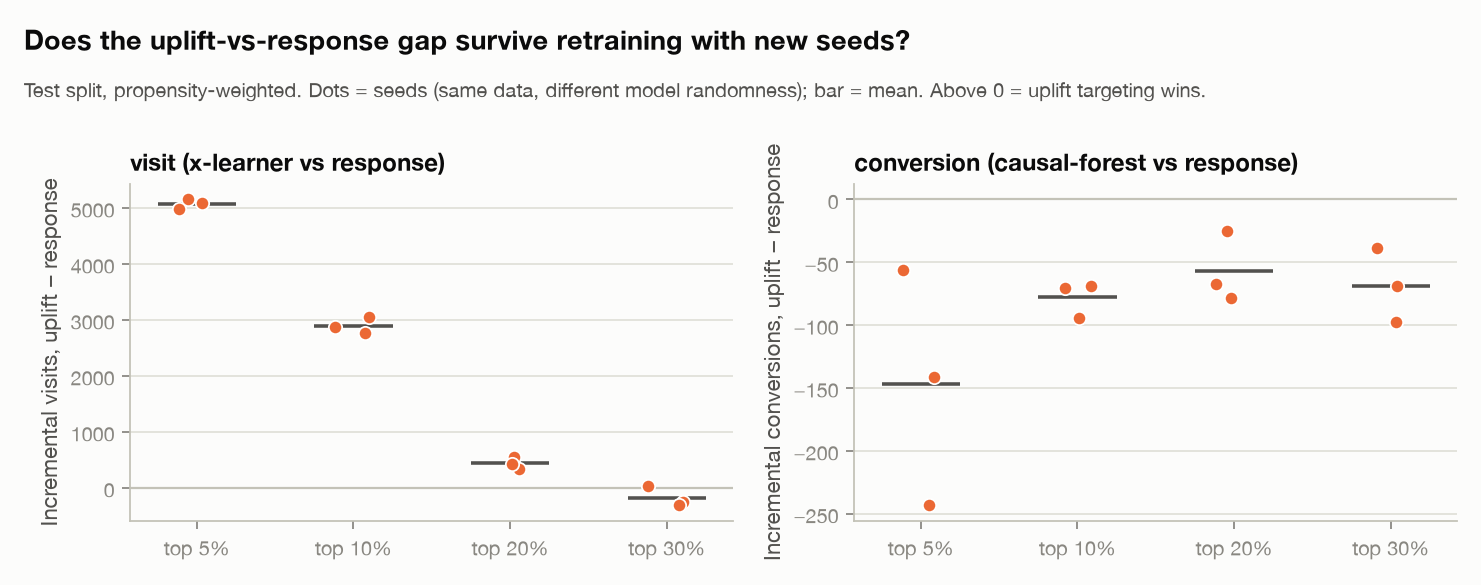

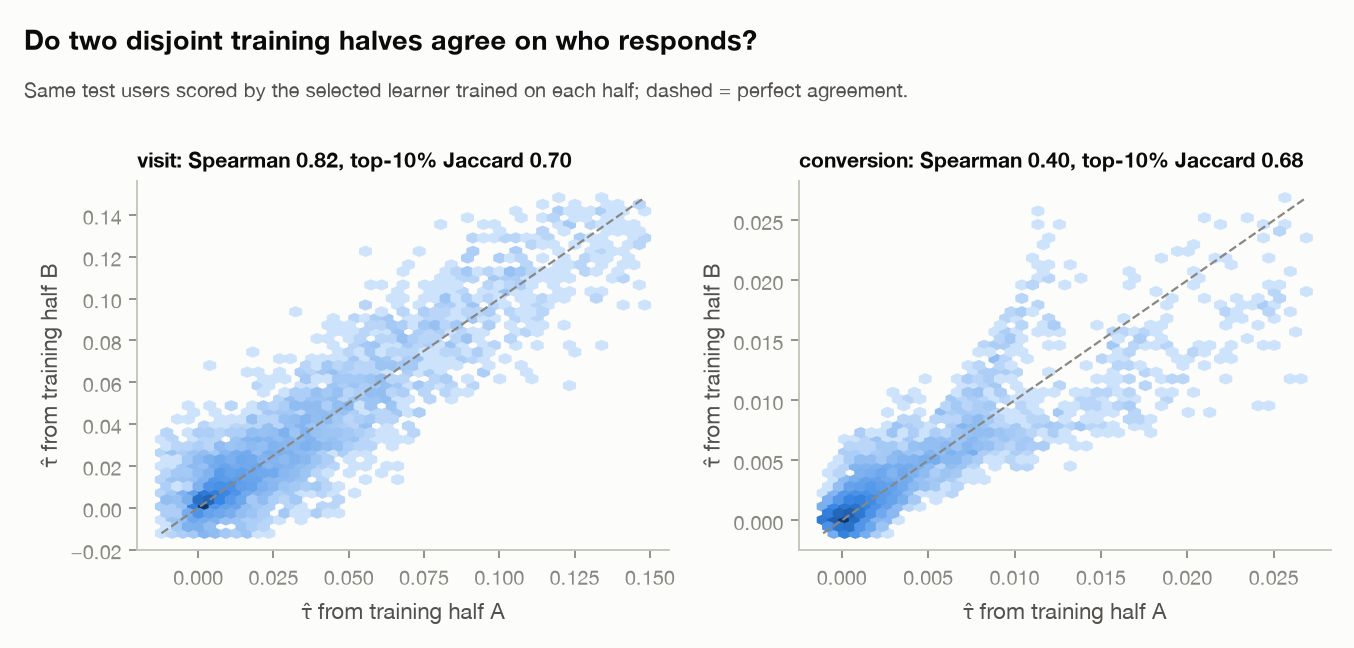

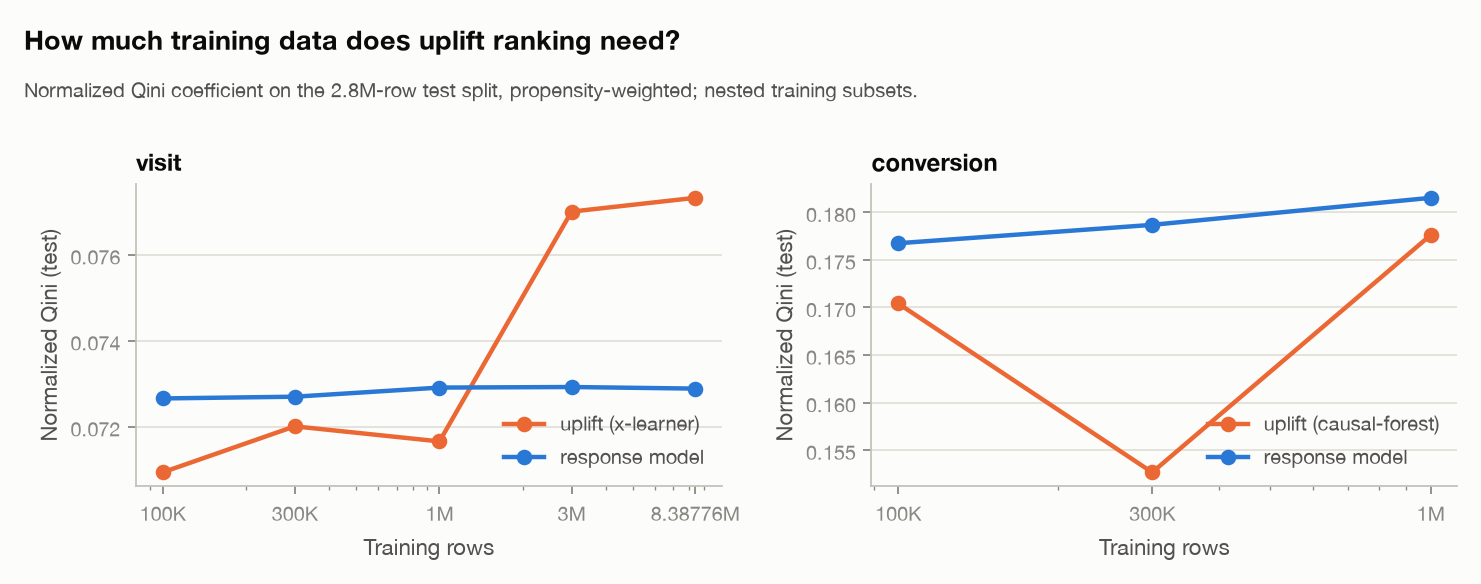

,model,arm,n,observed_rate,mean_predicted,predicted_over_observed,roc_auc,pr_auc
0,lightgbm,control,419387,0.001939,0.002683,1.384,0.9589,0.2243
1,lightgbm,treatment,2376531,0.003089,0.002958,0.9573,0.9578,0.2282
2,lightgbm_calibrated,control,419387,0.001939,0.002631,1.357,0.9589,0.2243
3,lightgbm_calibrated,treatment,2376531,0.003089,0.002897,0.9377,0.9578,0.2282
4,logistic_regression,control,419387,0.001939,0.002719,1.403,0.9577,0.2042
5,logistic_regression,treatment,2376531,0.003089,0.002965,0.9599,0.9555,0.217


In [13]:
if (MET / "robustness.json").exists():
    rb = metrics("robustness")
    print(json.dumps(rb["stability"], indent=1, default=str))
    fig("robustness_seed_stability"); fig("robustness_split_half"); fig("robustness_learning_curve")
    display(table("robustness_response_by_arm"))
else:
    print("run `make robustness` first")